In [8]:
#by Henry Schumacher
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import time
start_setup = time.time()
print('---------------------------------------')
print(time.strftime("PLS_results.ipynb started: %a, %d %b %Y %H:%M:%S", time.localtime()))
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import os
import sys
import json
import uuid
import h5py
import math
import tqdm
import xraydb
import plotly
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import numpy as np
import pandas as pd
# import pyxray as xy
import odrpack as odr
import seaborn as sb
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
import matplotlib.pyplot as plt
from concurrent.futures import ProcessPoolExecutor, as_completed
from matplotlib import ticker
from matplotlib.gridspec import GridSpec
from scipy.signal import find_peaks
from scipy.optimize import curve_fit
from scipy.special import voigt_profile
from scipy.ndimage import median_filter
from pybaselines import Baseline
from sklearn.metrics import root_mean_squared_error
from getmac import get_mac_address as gma
from itertools import chain
from matplotlib.offsetbox import OffsetImage, AnnotationBbox, TextArea, VPacker
from matplotlib.patches import Ellipse
from matplotlib.backends.backend_pdf import PdfPages
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
from colors import load_colors
from functions_pixe import *
from polygauss import *
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

from matplotlib import rc
# rc('font',**{'family':'sans-serif','sans-serif':['Helvetica']})
## for Palatino and other serif fonts use:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times"],
    "text.usetex": True,
    "font.size": 8,
    "pgf.rcfonts": False
})


plt.rcParams.update({
    "pgf.texsystem": "pdflatex",
    "pgf.preamble": "\n".join([
          r'\usepackage{amsmath}',
     ]),
})

#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#
color_schemes = load_colors()


end_setup = time.time()
elapsed_setup = (end_setup - start_setup)

print(f'INFO: SETUP COMPLETE ({elapsed_setup:.4f} s)')
print('---------------------------------------')
#-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-o-#

---------------------------------------
PLS_results.ipynb started: Fri, 24 Jul 2026 08:40:49
INFO: SETUP COMPLETE (0.0008 s)
---------------------------------------


In [9]:
class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.ndarray):
            return obj.tolist()
        if isinstance(obj, np.integer):
            return int(obj)
        if isinstance(obj, np.floating):
            return float(obj)
        return super().default(obj)

def signal_to_noise(signal, noise):
    P_signal = np.mean(np.array(signal)**2)
    P_noise = np.mean(np.array(noise)**2)
    snr = 10*np.log10(P_signal/P_noise)
    
    print(f'Signal-To-Noise Ration SNR = {snr:.2f}.')
    
    return snr 

def rmse(data:list, fit:list, length:int):
    '''
    Root-Mean-Square-Error
    '''
    data = np.array(data)
    fit = np.array(fit)
    return root_mean_squared_error(data, fit)

def rmse_gcv(data:list, fit:list, length:int):
    '''
    Root-Mean-Square-Error gap-cross-validation
    compare: Eilers_2003
    '''

def both_chi_squared(bin_data:list, fit_data:list, params:list):
    bin_data = np.array(bin_data)
    fit_data = np.array(fit_data)
    dof = len(bin_data) - len(params)
    var = np.sqrt(np.var(bin_data))
    return sum(((fit_data-bin_data)/ var)**2), sum(((fit_data-bin_data)/ var)**2) / dof

def goodness_of_fit(bin_data:list, fit_data:list):
    bin_data = np.array(bin_data)
    fit_data = np.array(fit_data)
    
    rss = sum((bin_data - fit_data)**2)
    tss = sum((bin_data - np.average(bin_data))**2)
    return 1 - rss/tss

def arpls_baseline(bin_data:list, bins:list, lam:int = 1e2):
    bsl_fitter = Baseline(x_data=bins)
    
    baseline, params = bsl_fitter.arpls(bin_data, lam=lam, max_iter=2000)
    subtracted = bin_data - baseline
    return baseline, subtracted

def aspls_baseline(bin_data:list, bins:list, lam:int = 1e2):
    bsl_fitter = Baseline(x_data=bins)
    
    baseline, params = bsl_fitter.aspls(bin_data, lam=lam, max_iter=200)
    subtracted = bin_data - baseline
    return baseline, subtracted

In [10]:
def toy_model(N:int, snr:int, baseline_type:str, plot_flag:bool, D:int=0):
    rng = np.random.default_rng()
    
    x = np.linspace(0,8191,8192)
    # GAUSS
    heights = rng.integers(low=100, high=5e4, size=N)
    widths = rng.integers(low=10, high=100, size=N)
    centers = rng.integers(low=100, high=7600, size=N)
    # print(heights, widths, centers)
    gauss_info = []
    for i in range(0,N):
        gauss_info.append(heights[i])
        gauss_info.append(centers[i])
        gauss_info.append(widths[i])
        
    peak_data = multi_gauss(gauss_info, x)
    P_signal = np.mean(peak_data**2)
    
    # BASELINE
    if (baseline_type == 'sine'):
        if (N > 5):
            sine_amp = rng.uniform(low=10000, high=2000*N)
        else:
            sine_amp = rng.uniform(low=10000, high=10000 + 2000*N)
        sine_freq = rng.uniform(low=0.00025, high=0.0006)
        sine_shift = rng.uniform(low=0, high=10000)
        bsl_param = [sine_amp, sine_freq, sine_shift]
        baseline = sine_amp*np.sin(sine_freq*x + sine_shift)
    elif (baseline_type == 'lin'):
        offset = rng.uniform(low=-1000, high=10000)
        steep = rng.uniform(low=-4, high=4)
        bsl_param = [offset,steep]
        baseline = offset + x*steep
    elif (baseline_type == 'exp'):
        # a*e^{bx+c}
        exp_a = rng.uniform(low=10, high=20*N)
        exp_b = rng.uniform(low=-1e-3, high=-1e-4)
        exp_c = rng.uniform(low=4, high=8)
        bsl_param = [exp_a, exp_b, exp_c]
        baseline = exp_a*np.exp(exp_b*x + exp_c)
    elif (baseline_type == 'poly'):
        degree = D
        poly_param = rng.uniform(low=-0.2, high=0.2, size=D+1)
        poly = np.polynomial.polynomial.Polynomial(poly_param)
        baseline = poly(x/100)
        bsl_param = poly_param
    
       
    # NOISE
    P_noise = P_signal / (10**(snr/10))
    sigma_noise = np.sqrt(P_noise)
    noise = rng.normal(loc=0.0, scale=sigma_noise, size=8192)
    # print(noise)
    # print(f'SNR: {snr:.3f}')
    
    if (plot_flag == True):
        plt.figure(figsize=(20,4), dpi=250)
        plt.plot(x, peak_data, zorder=3, color='black', label='pure data')
        plt.plot(x, peak_data + noise + baseline, zorder=2, color='firebrick', label='full synthetic data')
        # plt.plot(x, peak_data + baseline + 10000)
        plt.plot(x, baseline, color='teal', zorder=1, label='pure baseline')
        plt.grid(axis='y')
        plt.legend()
        plt.show()
    
    toy_model_data = {
        "Bins": x,
        "NumberOfPeaks": N,
        "SNR": snr,
        "GaussianPeaks": gauss_info,
        "Noise": noise,
        "BaselineType": baseline_type,
        "BaselineParameter": bsl_param,
        "Baseline": baseline,
        "SyntheticData": peak_data+noise+baseline       
    }
    return toy_model_data

In [20]:
def evaluate_baseline(toy_model_data:dict):
    
    plt.figure(figsize=(20,4), dpi=250)
    plt.grid(axis='y', which='both')
    
    lambda_range = np.linspace(4,14,2001)
    
    bins = toy_model_data['Bins']
    data = toy_model_data['SyntheticData']
    real_bsl = toy_model_data['Baseline']
    lam_min = [0,0]
    minimum = [1e5,1e5]
    res_list = [[],[]]
    for lam in tqdm.tqdm(lambda_range):
        arpls_bsl,_ = arpls_baseline(data, bins, 10**lam)
        arpls_result = rmse(real_bsl,arpls_bsl, 8192)
        res_list[0].append(arpls_result)
        if arpls_result < minimum[0]:
            minimum[0] = arpls_result
            lam_min[0] = lam
        
        aspls_bsl,_ = aspls_baseline(data, bins, 10**lam)
        aspls_result = rmse(real_bsl,aspls_bsl, 8192)
        res_list[1].append(aspls_result)
        if aspls_result < minimum[1]:
            minimum[1] = aspls_result
            lam_min[1] = lam
            
        # print(f'{lam:.4f}: {result:.4f}')
        # plt.plot(bins,arpls_bsl)
    # plt.plot(bins,real_bsl, color='black')
    plt.plot(lambda_range,res_list[0],label=r'non-erPLS $\rightarrow$ arPLS')
    plt.plot(lambda_range,res_list[1],label=r'non-erPLS $\rightarrow$ asPLS')
    plt.legend()
    plt.ylim(1,20000)
    plt.yscale('log')
    print(f'arPLS: Minimum: {lam_min[0]:.2f}: {minimum[0]:.2f} / {(minimum[0]/(data.mean())):.3f}')
    print(f'asPLS: Minimum: {lam_min[1]:.2f}: {minimum[1]:.2f} / {(minimum[1]/(data.mean())):.3f}')
    
    
    as_min,_ = aspls_baseline(data, bins, 10**lam_min[1])
    ar_min,_ = arpls_baseline(data, bins, 10**lam_min[0])
    
    plt.figure(figsize=(20,4), dpi=250)
    plt.grid(axis='y', which='both')
    plt.plot(bins, real_bsl, label='real Baseline')
    plt.plot(bins, as_min, label=r'non-erPLS $\rightarrow$ asPLS Baseline')
    plt.plot(bins, ar_min, label=r'non-erPLS $\rightarrow$ arPLS Baseline')
    plt.legend()
    return {
        "arpls_lambda": lam_min[0],
        "arpls_rmse": minimum[0],
        "aspls_lambda": lam_min[1],
        "aspls_rmse": minimum[1]}   
    
def evaluate_ext_baseline(x_new, y_new, y_e, synth_base):
    
    plt.figure(figsize=(20,4), dpi=250)
    plt.grid(axis='y', which='both')
    
    lambda_range = np.linspace(4,14,2001)
    
    bins = x_new
    data = y_new
    real_bsl = np.append(synth_base, y_e)
    real_ye_bsl = y_e
    
    lam_min = [0,0,0,0]
    minimum = [1e5,1e5,1e5,1e5]
    res_list = [[],[],[],[]]
    for lam in tqdm.tqdm(lambda_range):
        arpls_bsl,_ = arpls_baseline(data, bins, 10**lam)
        arpls_result = rmse(real_bsl,arpls_bsl, 8191+len(y_e))
        arpls_result_ye = rmse(real_ye_bsl,arpls_bsl[-len(y_e):], len(y_e))
        res_list[0].append(arpls_result)
        res_list[1].append(arpls_result_ye)
        if arpls_result < minimum[0]:
            minimum[0] = arpls_result
            lam_min[0] = lam
        if arpls_result_ye < minimum[1]:
            minimum[1] = arpls_result_ye
            lam_min[1] = lam
        
        aspls_bsl,_ = aspls_baseline(data, bins, 10**lam)
        aspls_result = rmse(real_bsl,aspls_bsl, 8191+len(y_e))
        aspls_result_ye = rmse(real_ye_bsl,aspls_bsl[-len(y_e):], len(y_e))
        res_list[2].append(aspls_result)
        res_list[3].append(aspls_result_ye)
        if aspls_result < minimum[2]:
            minimum[2] = aspls_result
            lam_min[2] = lam
        if aspls_result_ye < minimum[3]:
            minimum[3] = aspls_result_ye
            lam_min[3] = lam
        # print(f'{lam:.4f}: {result:.4f}')
        # plt.plot(bins,arpls_bsl)
    # plt.plot(bins,real_bsl, color='black')
    plt.plot(lambda_range,res_list[0],label=r'erPLS $\rightarrow$ arPLS (synth.)')
    plt.plot(lambda_range,res_list[1],label=r'erPLS $\rightarrow$ arPLS (synth. + ext.)')
    plt.plot(lambda_range,res_list[2],label=r'erPLS $\rightarrow$ asPLS (synth.)')
    plt.plot(lambda_range,res_list[3],label=r'erPLS $\rightarrow$ asPLS (synth. + ext.)')
    plt.legend()
    plt.ylim(1,20000)
    plt.yscale('log')
    print(f'arPLS (synth.): Minimum: {lam_min[0]:.2f}: {minimum[0]:.2f}')
    print(f'arPLS (synth. + ext.): Minimum: {lam_min[1]:.2f}: {minimum[1]:.2f} / {(minimum[1]/minimum[0]):.3f}')
    print(f'asPLS (synth.): Minimum: {lam_min[2]:.2f}: {minimum[2]:.2f}')
    print(f'asPLS (synth. + ext.): Minimum: {lam_min[3]:.2f}: {minimum[3]:.2f} / {(minimum[3]/minimum[2]):.3f}')
    
    
    ar_min,_    = arpls_baseline(data, bins, 10**lam_min[0])
    ar_min_ye,_ = arpls_baseline(data, bins, 10**lam_min[1])
    as_min,_    = aspls_baseline(data, bins, 10**lam_min[2])
    as_min_ye,_ = aspls_baseline(data, bins, 10**lam_min[3])
    
    plt.figure(figsize=(20,4), dpi=250)
    plt.grid(axis='y', which='both')
    # plt.plot(bins, real_bsl, label='real full Baseline')
    # plt.plot(bins[-len(y_e):], real_ye_bsl, label='real extended Baseline')
    plt.plot(bins, real_bsl - ar_min,      label=r'erPLS $\rightarrow$ asPLS Baseline (synth.)')
    plt.plot(bins, real_ye_bsl - ar_min_ye,   label=r'erPLS $\rightarrow$ arPLS Baseline (synth. + ext.)')
    plt.plot(bins, real_bsl - as_min,      label=r'erPLS $\rightarrow$ asPLS Baseline (synth.)')
    plt.plot(bins, real_ye_bsl - as_min_ye,   label=r'erPLS $\rightarrow$ arPLS Baseline (synth. + ext.)')
    plt.legend()
    return {
        "arpls_lambda": lam_min[0],
        "arpls_rmse": minimum[0],
        "arpls_ye_lambda": lam_min[1],
        "arpls_ye_rmse": minimum[1],
        "aspls_lambda": lam_min[2],
        "aspls_rmse": minimum[2],
        "aspls_ye_lambda": lam_min[3],
        "aspls_ye_rmse": minimum[3]}   
    

## erPLS

The Method, as described in _Zhang et al. 2020_ needs three parameters, complemented here with a forth.

$N$: The length of the original spectrum. Integer number, commonly 8192.

$\nu$: The fraction of length of $N$ that the extension shall have, proposed as 20.

$\Omega$: The length of used region of $N$ for the extension: $N/\nu$.

$W/2$: The width of the added Gaussian, proposed as $\Omega/5$.

$H$: The height of the added Gaussian, proposed as $max(Y(N))$.

In [14]:
def lin_fit_erPLS(toy_model:dict, Omega:int):
    '''
    STEP 1
    '''
    x = np.array(toy_model['Bins'][-Omega:])
    y = toy_model['SyntheticData'][-Omega:]
    params = np.array([1,1])
    popt, _ = curve_fit(lin_func_cf, x, y, p0=params, maxfev=10000)
    return popt

def plot_lin_fit_erPLS(toy_model:dict, x_e:list, y_e:list, Omega:int, lin_coeffs:list):
    '''
    STEP 2
    '''
    plt.figure(figsize=(20,4), dpi=250)
    plt.grid(axis='y', which='both')
    plt.plot(toy_model['Bins'], toy_model['SyntheticData'], zorder=2, color=color_schemes['c_dark'][0], label='Synthetic spectrum')
    plt.plot(toy_model['Bins'][-Omega:], lin_func_cf(toy_model['Bins'][-Omega:], lin_coeffs[0], lin_coeffs[1]), zorder=2, color=color_schemes['c_light'][5], label='Used spectrum region')
    plt.plot(x_e, y_e, zorder=2, color=color_schemes['c_dark'][3], label='Extended linear region')
    plt.title('erPLS lin fit')
    plt.legend()
    plt.show()

def plot_lin_gauss_erPLS(toy_model:dict, x_e:list, y_e:list, Omega:int, lin_coeffs:list, W:float, H:float):
    '''
    STEP 3
    '''
    N = len(toy_model['Bins'])
    y_g = gauss_func_ODR(x_e, H, N+Omega/2, W/2)
    
    plt.figure(figsize=(20,4), dpi=250)
    plt.grid(axis='y', which='both')
    plt.plot(toy_model['Bins'], toy_model['SyntheticData'], zorder=2, color=color_schemes['c_dark'][0], label='Synthetic spectrum')
    plt.plot(x_e, y_e+y_g, zorder=2, color=color_schemes['c_dark'][3], label='Extended linear region incl. Gaussian')
    plt.legend()
    plt.title('erPLS lin fit + Gauss')
    plt.show()
    
    return y_e + y_g

def erPLS(toy_model:dict, nu:int, w:int):
    N = len(toy_model['Bins'])
    Omega = int(N/nu)
    W = Omega/w
    H = np.max(toy_model['SyntheticData'])
    x_e = np.arange(np.max(toy_model['Bins']),np.max(toy_model['Bins'])+Omega,1)
    
    lin_coeffs = lin_fit_erPLS(toy_model, Omega)
    y_e = lin_func_cf(x_e, lin_coeffs[0], lin_coeffs[1])
    plot_lin_fit_erPLS(toy_model, x_e, y_e, Omega, lin_coeffs)
    y_ext = plot_lin_gauss_erPLS(toy_model, x_e, y_e, Omega, lin_coeffs, W, H)
    
    y_new = np.append(toy_model['SyntheticData'],np.array(y_ext))
    x_new = np.append(toy_model['Bins'],x_e)
    evaluate_ext_baseline(x_new, y_new, y_e, toy_model['Baseline'])

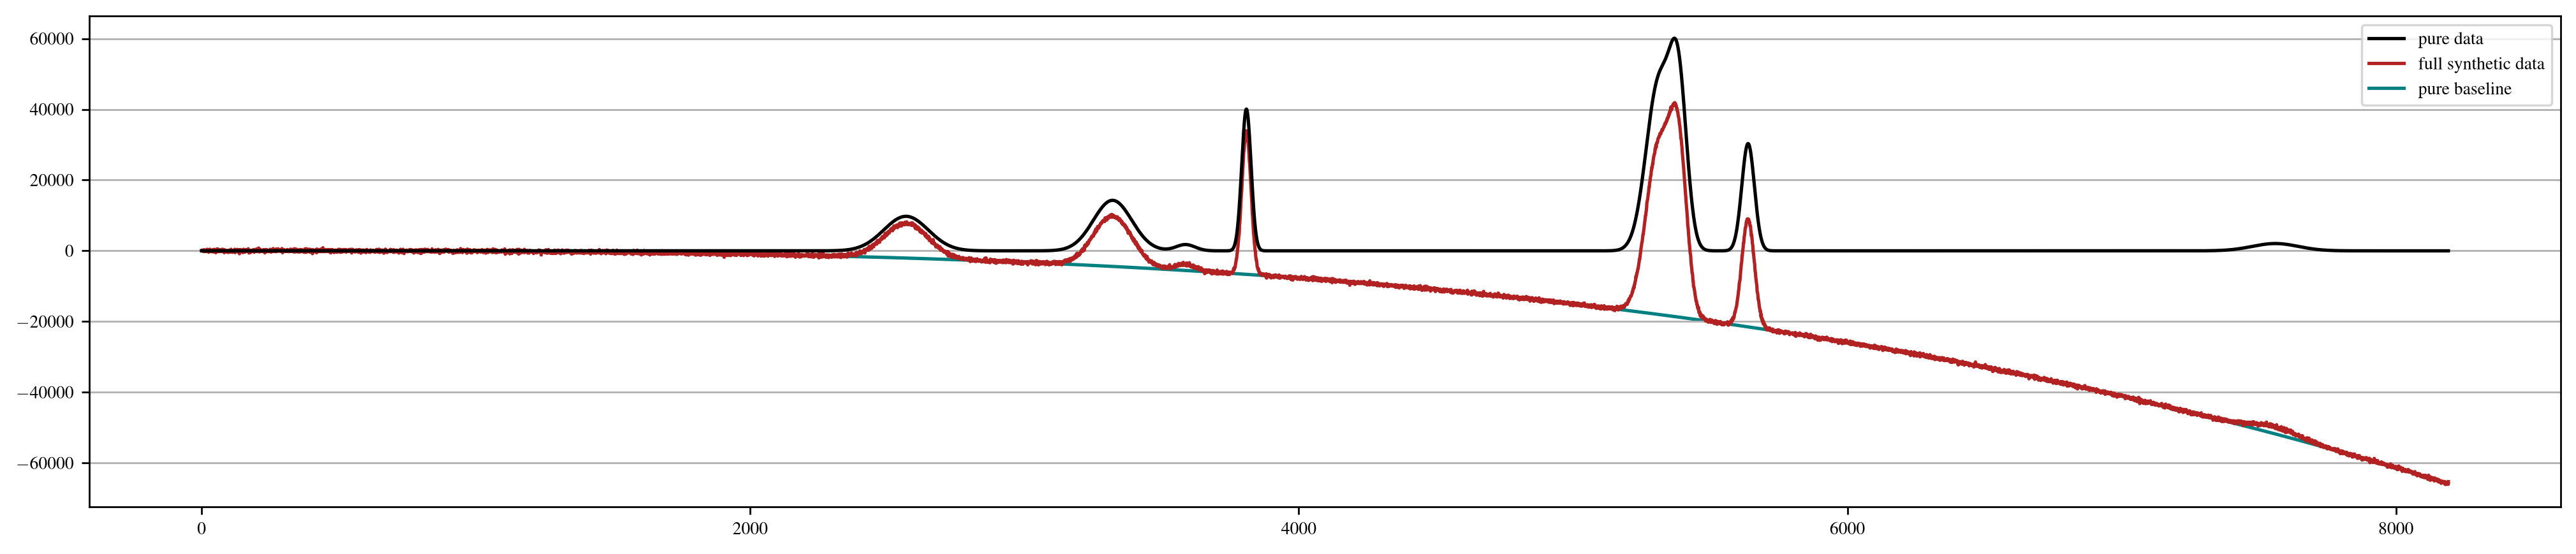

erPLS


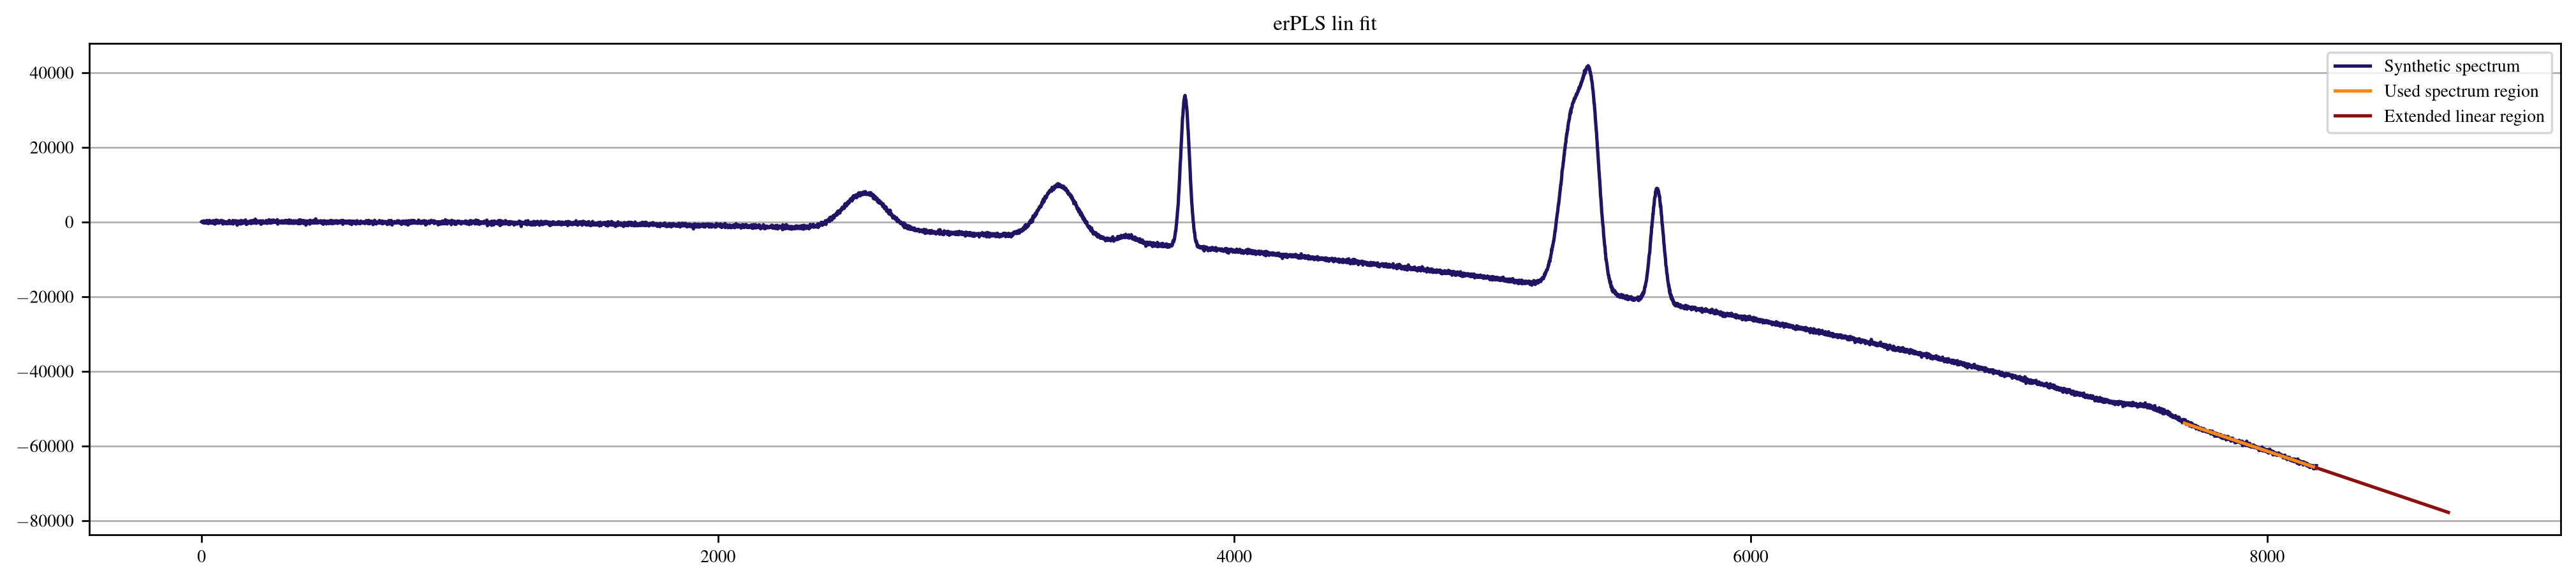

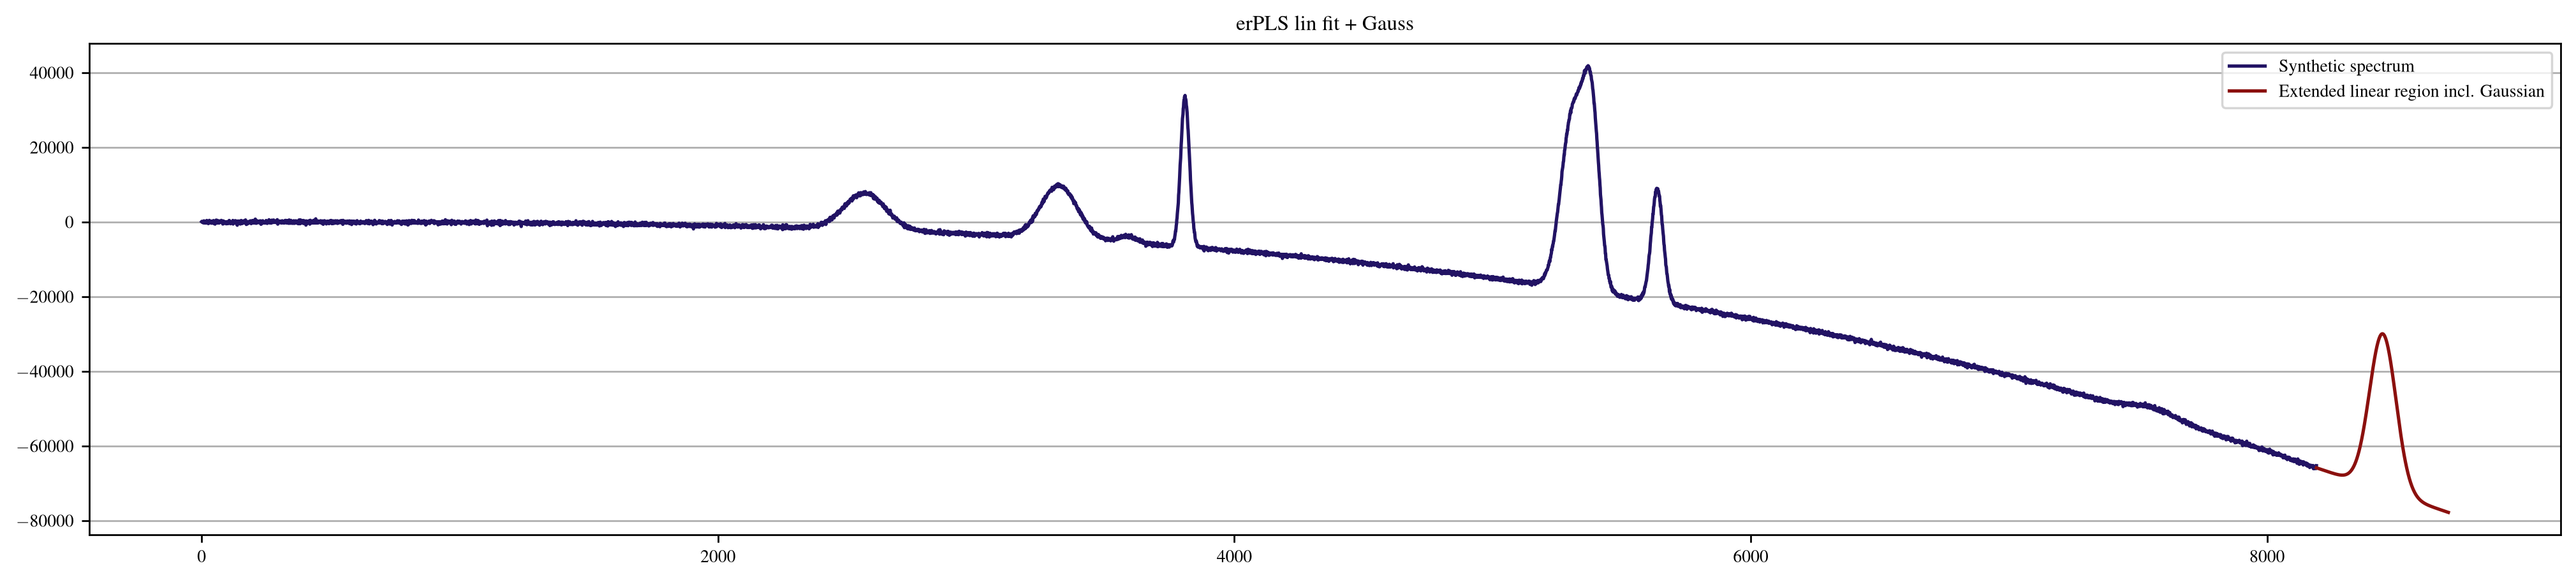

100%|██████████| 2001/2001 [01:42<00:00, 19.47it/s]


arPLS (synth.): Minimum: 9.23: 54.06
arPLS (synth. + ext.): Minimum: 8.53: 90.09 / 1.666
asPLS (synth.): Minimum: 11.15: 65.38
asPLS (synth. + ext.): Minimum: 11.09: 27.67 / 0.423


ValueError: operands could not be broadcast together with shapes (512,) (8704,) 

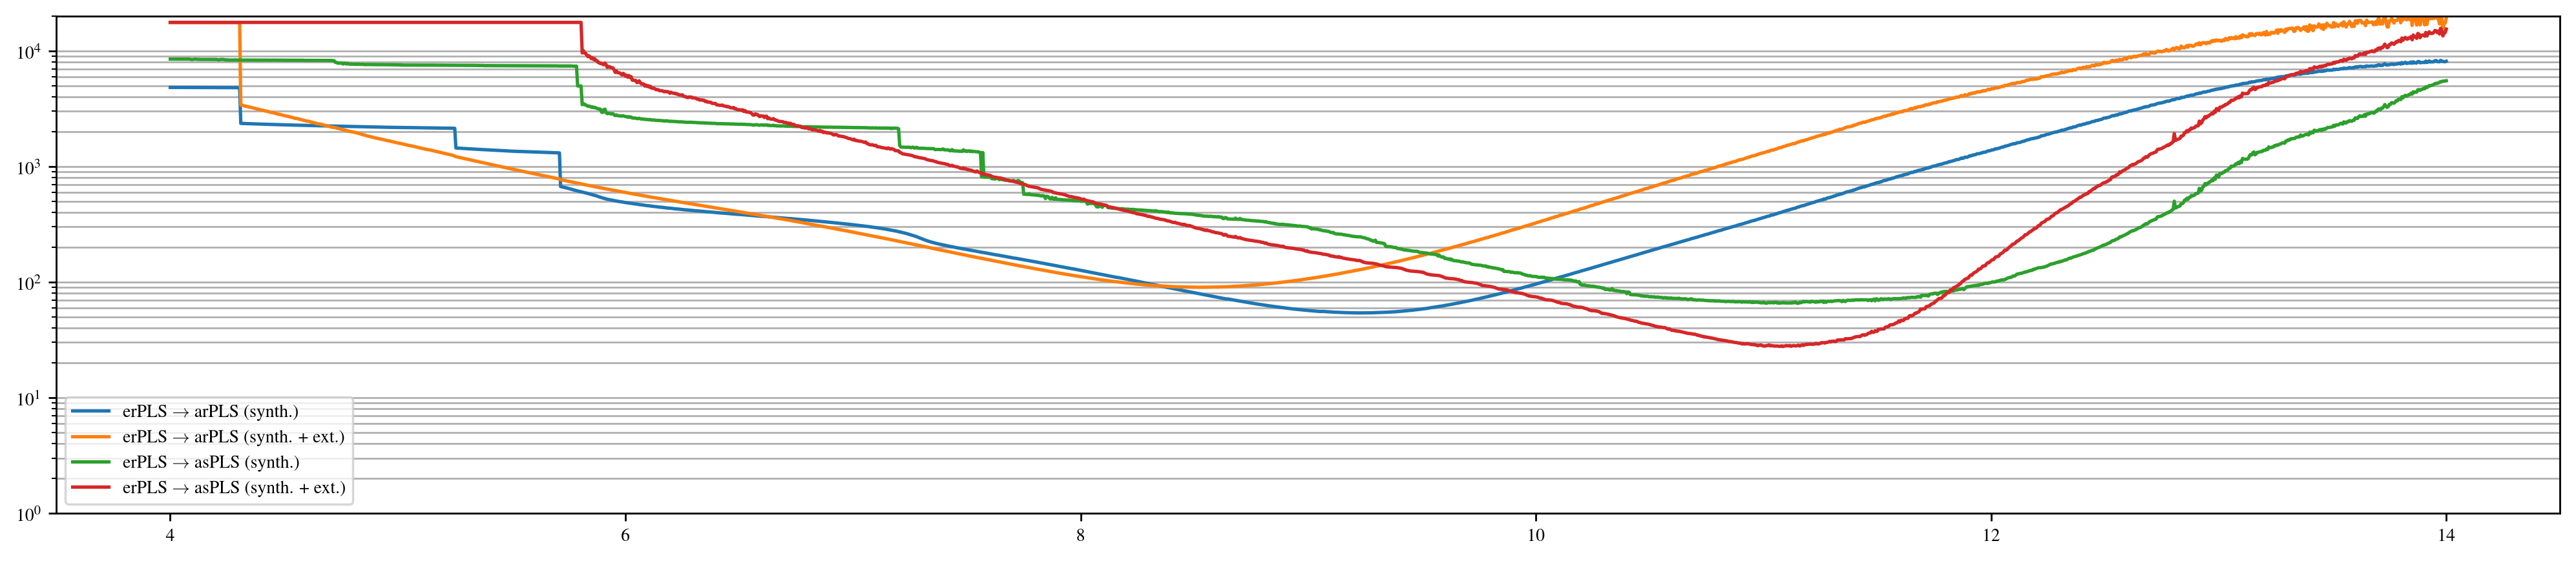

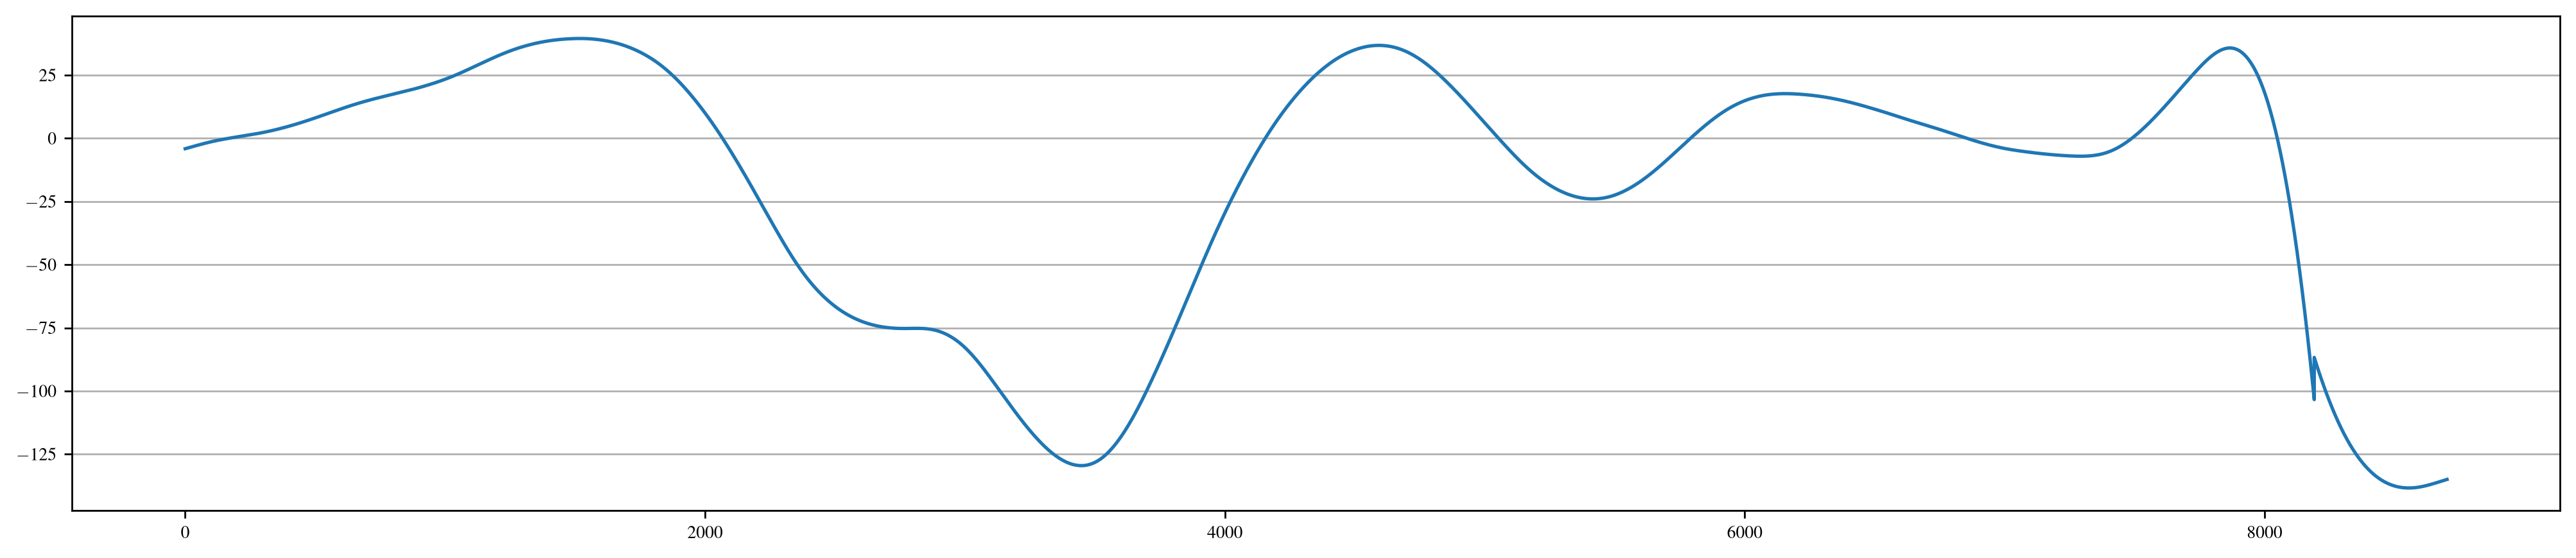

In [21]:
tmd = toy_model(N=8, snr=30, baseline_type='poly', plot_flag=True, D=3)

# print(tmd)
print('erPLS')
erPLS(tmd, nu=16, w=5)

print('non-erPLS')
evaluate_baseline(tmd)

# tmd = toy_model(N=8, snr=20, baseline_type='poly', plot_flag=True, D=3)

# # print(tmd)

# print('erPLS')
# erPLS(tmd, nu=16, w=5)

# print('non-erPLS')
# evaluate_baseline(tmd)

# evaluate_baseline(tmd)